<a href="https://colab.research.google.com/github/pellegreeno/Bioestat-stica-2026-/blob/main/semin%C3%A1rio01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Seminário 01 de Bioestatística

Ana Carolina Sartori 17081013

Cris Serpa Guimarães 16860671

Julia Sztejnhaus Pamio 17072621

Maria Eduarda Pellegrino 17074112

In [ ]:
import pandas as pd
df = pd.read_excel('/content/msleep_data.xlsx')

In [ ]:
import pandas as pd

display(df.head(80))

,rownames,name,genus,vore,order,conservation,sleep_total,sleep_rem,sleep_cycle,awake,brainwt,bodywt
0,1,Cheetah,Acinonyx,carni,Carnivora,lc,12.1,NaN,NaN,11.9,NaN,50.000
1,2,Owl monkey,Aotus,omni,Primates,NaN,17.0,1.8,NaN,7.0,0.01550,0.480
2,3,Mountain beaver,Aplodontia,herbi,Rodentia,nt,14.4,2.4,NaN,9.6,NaN,1.350
3,4,Greater short-tailed shrew,Blarina,omni,Soricomorpha,lc,14.9,2.3,0.133333,9.1,0.00029,0.019
4,5,Cow,Bos,herbi,Artiodactyla,domesticated,4.0,0.7,0.666667,20.0,0.42300,600.000
...,...,...,...,...,...,...,...,...,...,...,...,...
75,76,Eastern american chipmunk,Tamias,herbi,Rodentia,NaN,15.8,NaN,NaN,8.2,NaN,0.112
76,77,Brazilian tapir,Tapirus,herbi,Perissodactyla,vu,4.4,1.0,0.900000,19.6,0.16900,207.501
77,78,Tenrec,Tenrec,omni,Afrosoricida,NaN,15.6,2.3,NaN,8.4,0.00260,0.900
78,79,Tree shrew,Tupaia,omni,Scandentia,NaN,8.9,2.6,0.233333,15.1,0.00250,0.104


Os dados referem-se a uma versão expandida e atualizada de dados sobre o sono de mamíferos. Eles são utilizados para identificar e analisar mudanças de comportamento e impactos ecológicos a longo prazo.

As variáveis analisadas são:
- "rownames" = apenas um identificador de linha;
- "name" = nome popular do mamífero;
- "genus" = gênero do mamífero;
- "vore" = tipo de alimentação (podendo ser "herbi" para herbívoro, "omni" para omnívoro, "carni" para carnívoro ou "insecti" para insetívoro);
- "order" = ordem taxonômica do mamífero;
- "conservation" = status de conservação da espécie (podendo ser "lc" para menor preocupação, "nt" para quase ameaçado ou "domesticated" para domesticado);
- "sleep_total" = tempo total de sono em horas por dia;
- "sleep_rem" = tempo de sono REM (Rapid Eye Movement) em horas por dia;
- "sleep_cycle" = tempo do ciclo de sono, ou seja, duração de um ciclo completo de sono em horas;
- "awake" = tempo em que o mamífero para acordado em horas por dia;
- "brainwt" = peso do cérebro em quilogramas;
- "bodywt" = peso corporal em quilogramas.

Obs: "NaN" (Not a Number) indica dados ausentes.

##Tipos de Variáveis
**Categóricas**: vore (dieta: herbívoro, carnívoro, onívoro, insetívoro — 7 NAs), order (ordem taxonômica, 19 categorias, muito desbalanceada), conservation (status de conservação, 29 NAs)

**Numéricas**: sleep_total, sleep_rem, sleep_cycle, awake, brainwt, bodywt

### Ficha Técnica dos Dados Numéricos

In [ ]:
numerical_cols = ['sleep_total', 'sleep_rem', 'sleep_cycle', 'awake', 'brainwt', 'bodywt']

display(df[numerical_cols].describe())

,sleep_total,sleep_rem,sleep_cycle,awake,brainwt,bodywt
count,83.000000,61.000000,32.000000,83.000000,56.000000,83.000000
mean,10.433735,1.875410,0.439583,13.567470,0.281581,166.136349
std,4.450357,1.298288,0.358680,4.452085,0.976414,786.839732
min,1.900000,0.100000,0.116667,4.100000,0.000140,0.005000
25%,7.850000,0.900000,0.183333,10.250000,0.002900,0.174000
50%,10.100000,1.500000,0.333333,13.900000,0.012400,1.670000
75%,13.750000,2.400000,0.579167,16.150000,0.125500,41.750000
max,19.900000,6.600000,1.500000,22.100000,5.712000,6654.000000


### Comparação de `bodywt` entre grupos com/sem `sleep_cycle`

In [ ]:
import numpy as np

# Create a new column 'tem_sleep_cycle' (has_sleep_cycle)
df['tem_sleep_cycle'] = df['sleep_cycle'].notna().astype(int)

# Apply log transformation to 'bodywt' for better distribution visualization
df['log_bodywt'] = df['bodywt'].apply(lambda x: np.log1p(x)) # Using log1p to handle zero values

display(df[['sleep_cycle', 'tem_sleep_cycle', 'bodywt', 'log_bodywt']].head())

,sleep_cycle,tem_sleep_cycle,bodywt,log_bodywt
0,NaN,0,50.000,3.931826
1,NaN,0,0.480,0.392042
2,NaN,0,1.350,0.854415
3,0.133333,1,0.019,0.018822
4,0.666667,1,600.000,6.398595


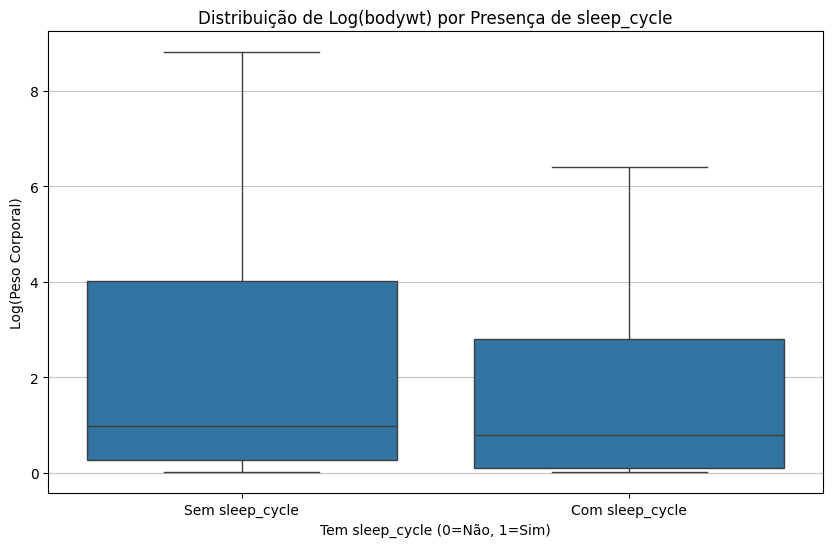


Mann-Whitney U Test: statistic=941.00, p-value=0.244
Não há diferença estatisticamente significativa no log(bodywt) entre os grupos.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu

plt.figure(figsize=(10, 6))
sns.boxplot(x='tem_sleep_cycle', y='log_bodywt', data=df)
plt.title('Distribuição de Log(bodywt) por Presença de sleep_cycle')
plt.xlabel('Tem sleep_cycle (0=Não, 1=Sim)')
plt.ylabel('Log(Peso Corporal)')
plt.xticks([0, 1], ['Sem sleep_cycle', 'Com sleep_cycle'])
plt.grid(axis='y', alpha=0.75)
plt.show()

# Perform Mann-Whitney U test
group_no_sleep_cycle = df[df['tem_sleep_cycle'] == 0]['log_bodywt'].dropna()
group_with_sleep_cycle = df[df['tem_sleep_cycle'] == 1]['log_bodywt'].dropna()

# Check if both groups have enough data for the test
if len(group_no_sleep_cycle) > 0 and len(group_with_sleep_cycle) > 0:
    stat, p_value = mannwhitneyu(group_no_sleep_cycle, group_with_sleep_cycle)
    print(f'\nMann-Whitney U Test: statistic={stat:.2f}, p-value={p_value:.3f}')
    if p_value < 0.05:
        print('Há uma diferença estatisticamente significativa no log(bodywt) entre os grupos.')
    else:
        print('Não há diferença estatisticamente significativa no log(bodywt) entre os grupos.')
else:
    print('\nNão foi possível realizar o Mann-Whitney U Test, um ou ambos os grupos não possuem dados suficientes.')

### Comparação de `bodywt` entre grupos com/sem `sleep_rem`

In [ ]:
# Create a new column 'tem_sleep_rem' (has_sleep_rem)
df['tem_sleep_rem'] = df['sleep_rem'].notna().astype(int)

display(df[['sleep_rem', 'tem_sleep_rem', 'bodywt', 'log_bodywt']].head())

,sleep_rem,tem_sleep_rem,bodywt,log_bodywt
0,NaN,0,50.000,3.931826
1,1.8,1,0.480,0.392042
2,2.4,1,1.350,0.854415
3,2.3,1,0.019,0.018822
4,0.7,1,600.000,6.398595


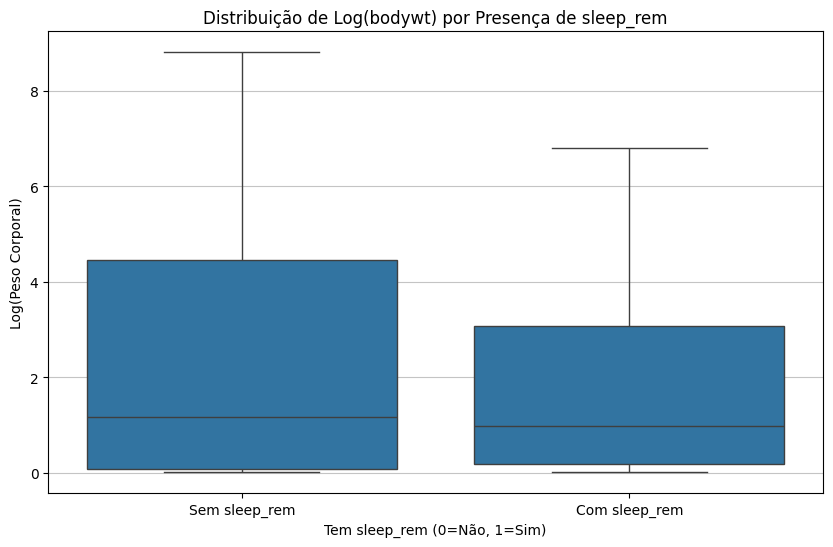


Mann-Whitney U Test for sleep_rem: statistic=703.50, p-value=0.741
Não há diferença estatisticamente significativa no log(bodywt) entre os grupos para sleep_rem.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

plt.figure(figsize=(10, 6))
sns.boxplot(x='tem_sleep_rem', y='log_bodywt', data=df)
plt.title('Distribuição de Log(bodywt) por Presença de sleep_rem')
plt.xlabel('Tem sleep_rem (0=Não, 1=Sim)')
plt.ylabel('Log(Peso Corporal)')
plt.xticks([0, 1], ['Sem sleep_rem', 'Com sleep_rem'])
plt.grid(axis='y', alpha=0.75)
plt.show()

# Perform Mann-Whitney U test
group_no_sleep_rem = df[df['tem_sleep_rem'] == 0]['log_bodywt'].dropna()
group_with_sleep_rem = df[df['tem_sleep_rem'] == 1]['log_bodywt'].dropna()

# Check if both groups have enough data for the test
if len(group_no_sleep_rem) > 0 and len(group_with_sleep_rem) > 0:
    stat_rem, p_value_rem = mannwhitneyu(group_no_sleep_rem, group_with_sleep_rem)
    print(f'\nMann-Whitney U Test for sleep_rem: statistic={stat_rem:.2f}, p-value={p_value_rem:.3f}')
    if p_value_rem < 0.05:
        print('Há uma diferença estatisticamente significativa no log(bodywt) entre os grupos para sleep_rem.')
    else:
        print('Não há diferença estatisticamente significativa no log(bodywt) entre os grupos para sleep_rem.')
else:
    print('\nNão foi possível realizar o Mann-Whitney U Test para sleep_rem, um ou ambos os grupos não possuem dados suficientes.')

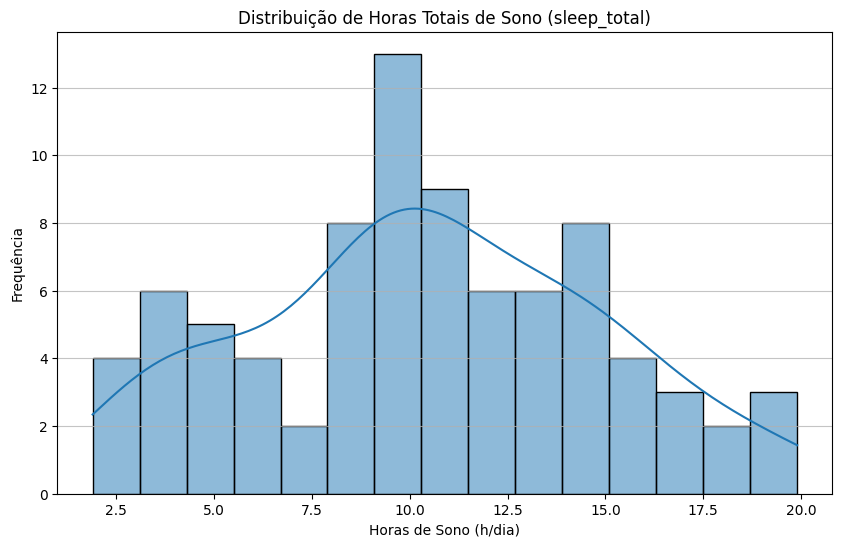

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['sleep_total'].dropna(), bins=15, kde=True)
plt.title('Distribuição de Horas Totais de Sono (sleep_total)')
plt.xlabel('Horas de Sono (h/dia)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

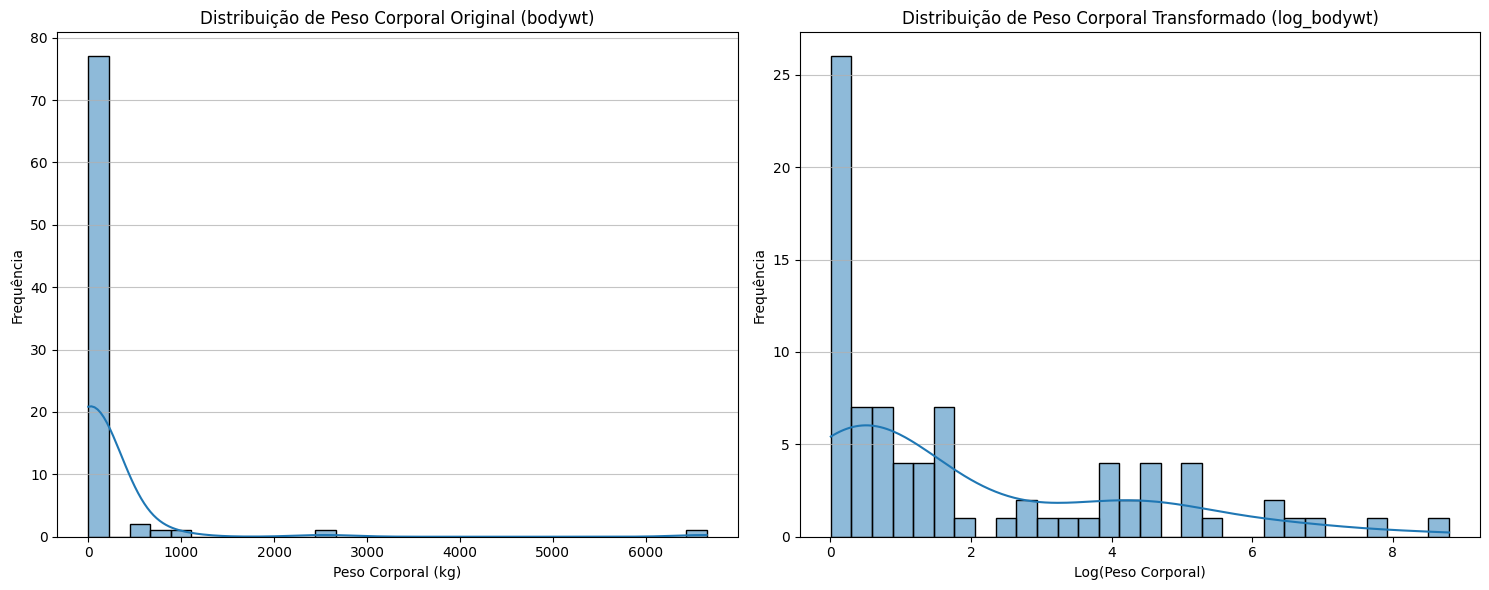

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # Ensure numpy is imported for log1p if df['log_bodywt'] was not created yet, though it should be by now

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for original 'bodywt'
sns.histplot(df['bodywt'].dropna(), bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribuição de Peso Corporal Original (bodywt)')
axes[0].set_xlabel('Peso Corporal (kg)')
axes[0].set_ylabel('Frequência')
axes[0].grid(axis='y', alpha=0.75)

# Histogram for log-transformed 'log_bodywt'
sns.histplot(df['log_bodywt'].dropna(), bins=30, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Peso Corporal Transformado (log_bodywt)')
axes[1].set_xlabel('Log(Peso Corporal)')
axes[1].set_ylabel('Frequência')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

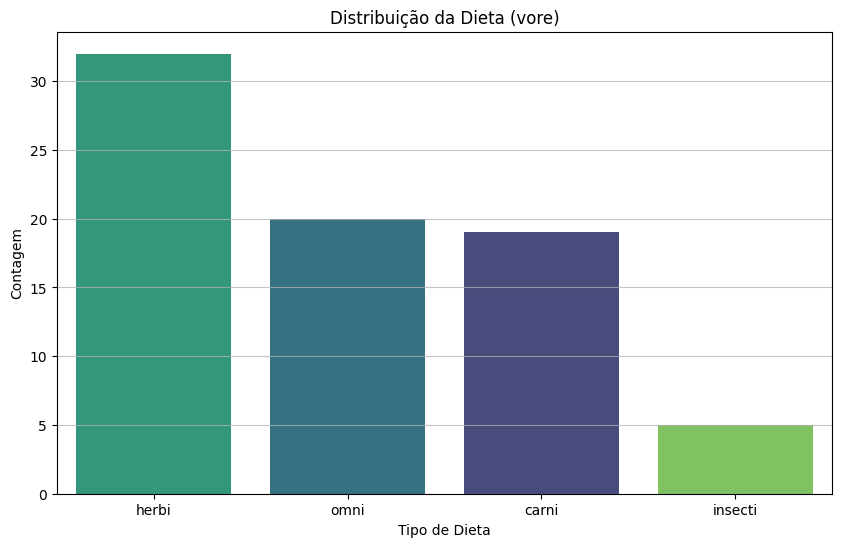

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for 'vore'
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='vore', order=df['vore'].value_counts().index, hue='vore', palette='viridis', legend=False)
plt.title('Distribuição da Dieta (vore)')
plt.xlabel('Tipo de Dieta')
plt.ylabel('Contagem')
plt.grid(axis='y', alpha=0.75)
plt.show()

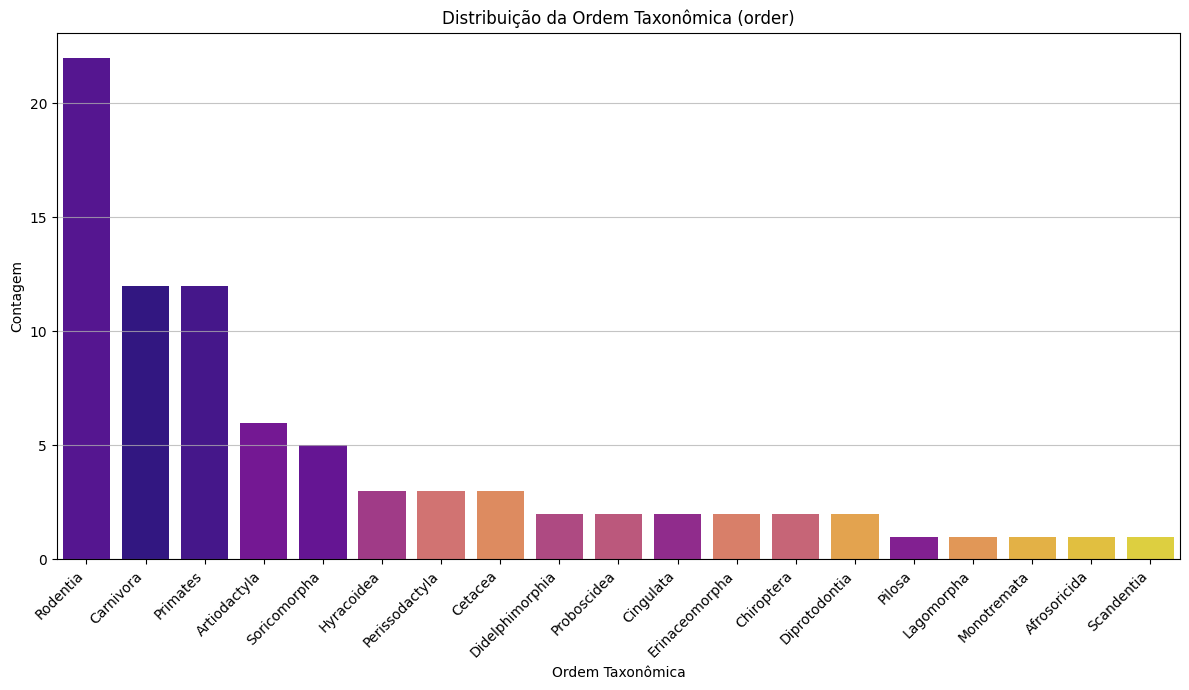

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot for 'order'
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='order', order=df['order'].value_counts().index, hue='order', palette='plasma', legend=False)
plt.title('Distribuição da Ordem Taxonômica (order)')
plt.xlabel('Ordem Taxonômica')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', alpha=0.75)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

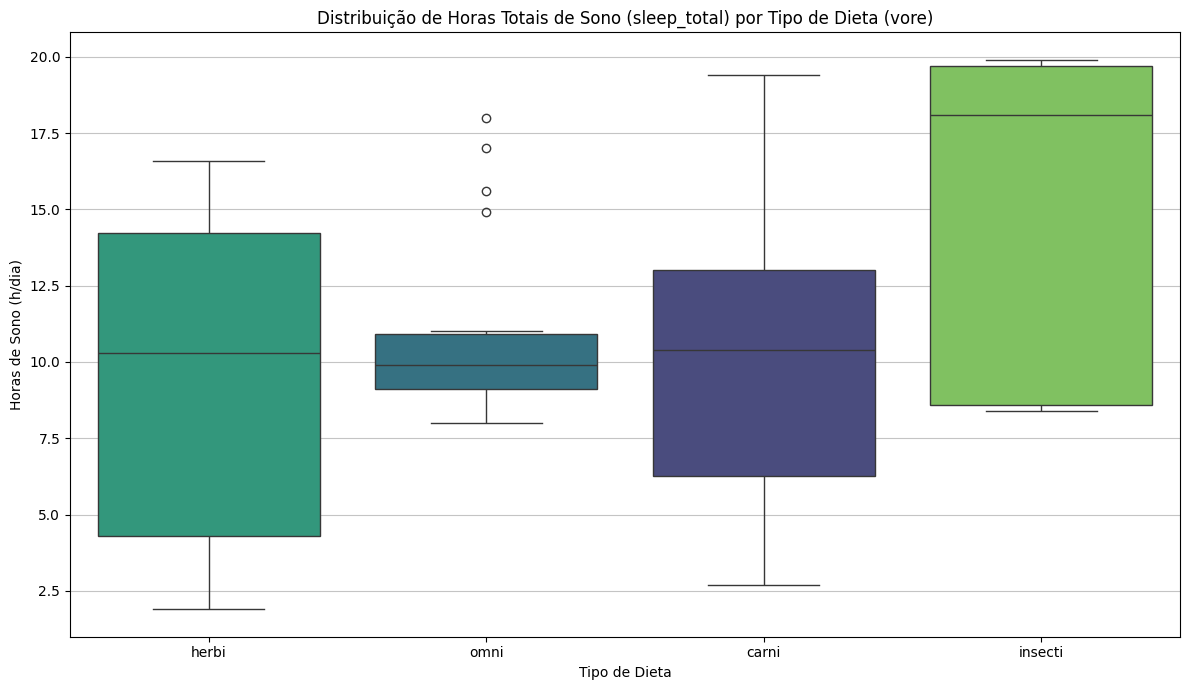

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
# Order 'vore' categories by their counts for better readability
vore_order = df['vore'].value_counts().index
sns.boxplot(data=df, x='vore', y='sleep_total', order=vore_order, hue='vore', palette='viridis', legend=False)
plt.title('Distribuição de Horas Totais de Sono (sleep_total) por Tipo de Dieta (vore)')
plt.xlabel('Tipo de Dieta')
plt.ylabel('Horas de Sono (h/dia)')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

### Heatmap de Correlação entre Variáveis Numéricas

Vamos visualizar a correlação entre as variáveis numéricas para entender suas relações. Serão utilizadas as correlações de Pearson.

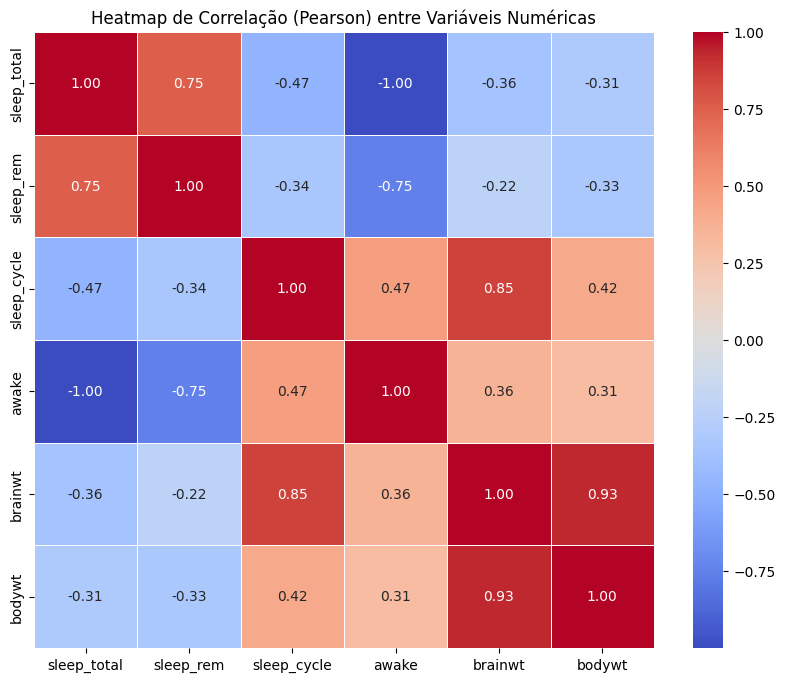

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr(method='pearson') # Ou 'spearman' para correlação de postos
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap de Correlação (Pearson) entre Variáveis Numéricas')
plt.show()

### Scatterplot: `log_bodywt` vs. `log_brainwt`

Vamos investigar a relação entre o peso corporal transformado (log) e o peso do cérebro transformado (log). Primeiramente, precisamos transformar a variável `brainwt` da mesma forma que `bodywt`.

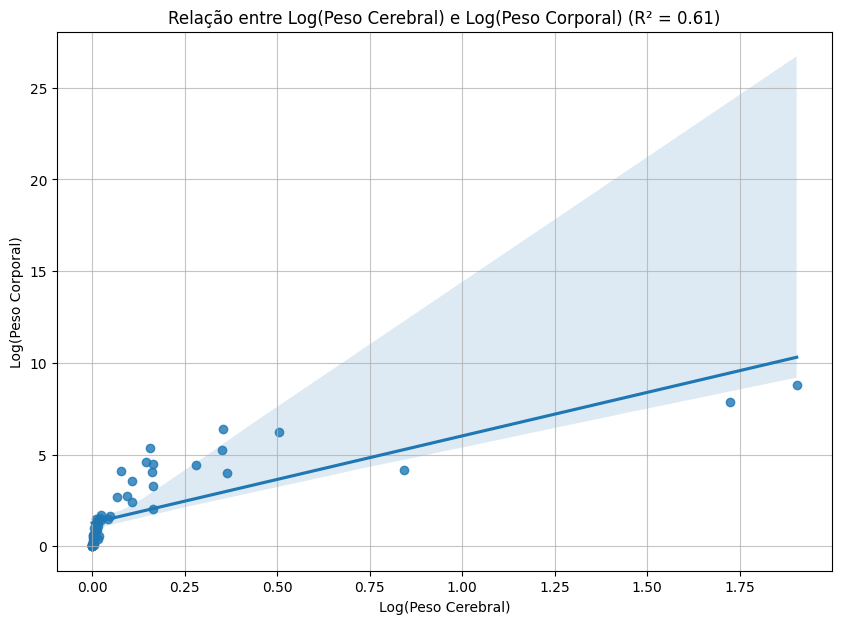

In [ ]:
import numpy as np
from scipy.stats import pearsonr

# Criar a coluna log_brainwt
df['log_brainwt'] = df['brainwt'].apply(lambda x: np.log1p(x))

# Filtrar NaN para o cálculo da correlação e o plot
df_filtered = df[['log_bodywt', 'log_brainwt']].dropna()

# Calcular a correlação Pearson e R-quadrado
correlation, _ = pearsonr(df_filtered['log_bodywt'], df_filtered['log_brainwt'])
r_squared = correlation**2

plt.figure(figsize=(10, 7))
sns.regplot(x='log_brainwt', y='log_bodywt', data=df)
plt.title(f'Relação entre Log(Peso Cerebral) e Log(Peso Corporal) (R² = {r_squared:.2f})')
plt.xlabel('Log(Peso Cerebral)')
plt.ylabel('Log(Peso Corporal)')
plt.grid(True, alpha=0.75)
plt.show()

### Scatterplot: `log_bodywt` vs. `sleep_total`

Agora, vamos explorar a relação entre o peso corporal transformado (log) e o tempo total de sono, para responder à pergunta: "Animais maiores dormem menos?"

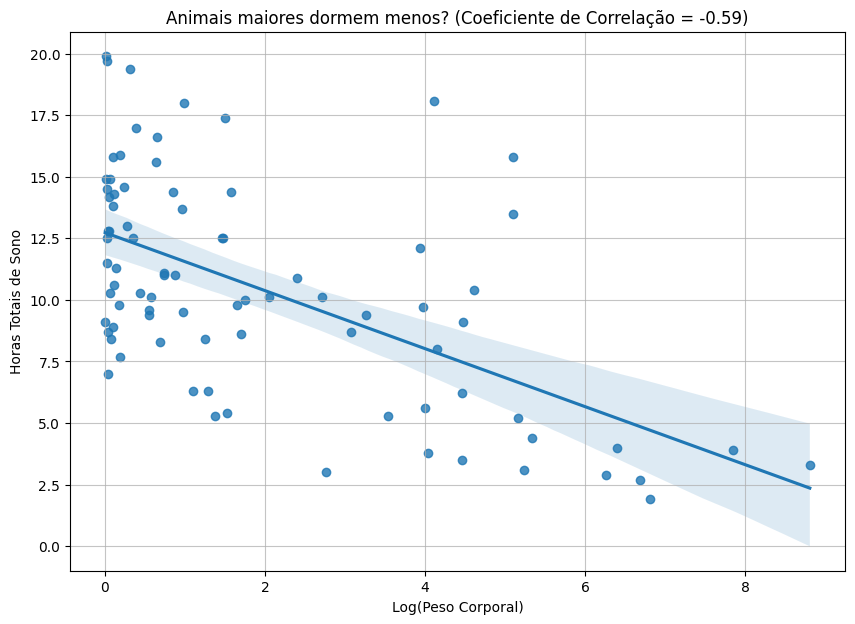

In [ ]:
from scipy.stats import pearsonr

# Filtrar NaN para o cálculo da correlação e o plot
df_filtered_sleep = df[['log_bodywt', 'sleep_total']].dropna()

# Calcular a correlação Pearson
correlation_sleep, _ = pearsonr(df_filtered_sleep['log_bodywt'], df_filtered_sleep['sleep_total'])

plt.figure(figsize=(10, 7))
sns.regplot(x='log_bodywt', y='sleep_total', data=df)
plt.title(f'Animais maiores dormem menos? (Coeficiente de Correlação = {correlation_sleep:.2f})')
plt.xlabel('Log(Peso Corporal)')
plt.ylabel('Horas Totais de Sono')
plt.grid(True, alpha=0.75)
plt.show()

### Porcentagem de Valores Faltantes por Variável

In [ ]:
import pandas as pd
df = pd.read_excel('/content/msleep_data.xlsx')

missing_percentages = df.isnull().sum() / len(df) * 100

# Filter for the requested variables
selected_missing_percentages = missing_percentages[['sleep_cycle', 'brainwt', 'sleep_rem']]

display(selected_missing_percentages.to_frame(name='Porcentagem Faltante').style.format('{:.2f}%'))

,Porcentagem Faltante
sleep_cycle,61.45%
brainwt,32.53%
sleep_rem,26.51%


**Referências**

Link do repositório "msleep - Mammals Sleep Dataset":
https://www.kaggle.com/datasets/pereyrax/msleep-mammals-sleep-dataset

Informações retiradas de:
- V. M. Savage
- G. B. West
- National Academy of Sciences, 104 (3):1051-1056, 2007